<a href="https://colab.research.google.com/github/debugvivaanbhimani/infomatrixboot/blob/main/infomatrix_python_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

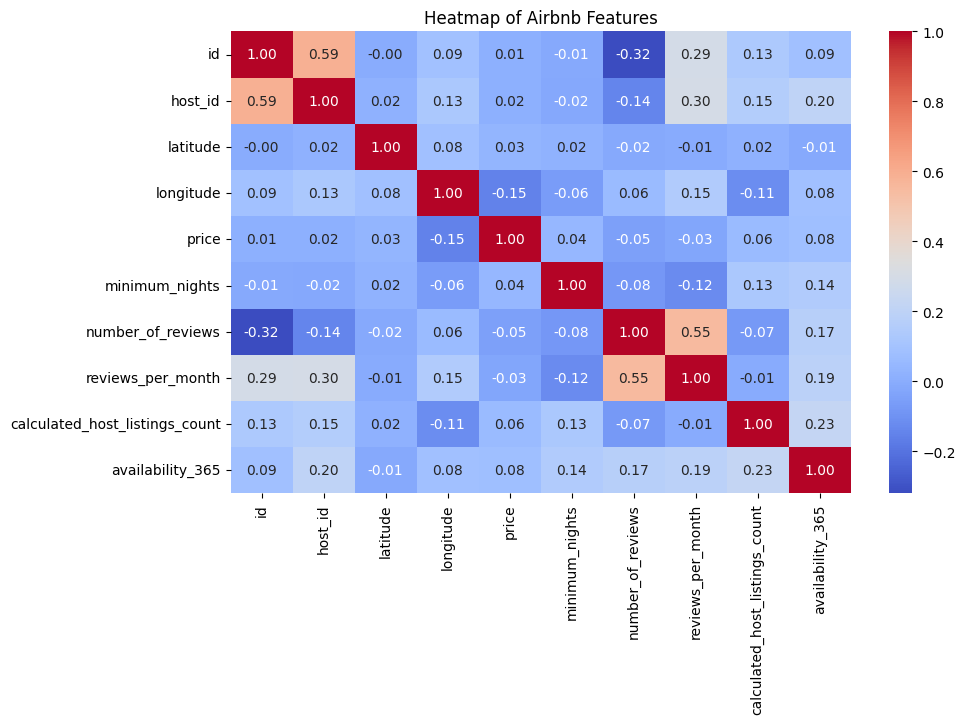

Basic Model
R^2 Score : 0.038160139801327375
MAE : 84.43482922328619
MSE : 42550.10057029462
RMSE : 206.27675722265613
Full model
R^2 Score : 0.12100818229695942
MAE : 70.79056267360998
MSE : 38885.049155693196
RMSE : 197.19292369578883


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# 1. NYC AirBnb open data
# Linear Regression problem as
# 2. Target feature is price

df = pd.read_csv("AB_NYC_2019.csv")

print(df.head())

#preprocessing and EDA

print("\n--- EDA ---")
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

#Heatmap

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap of Airbnb Features")
plt.show()


#missing values

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)


df = df.drop(["id", "name", "host_id", "host_name", "last_review", "neighbourhood"], axis=1)


df = pd.get_dummies(df, drop_first=True)



print("Basic Model")

X_basic = df[["latitude", "longitude", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]]
y_basic = df["price"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_basic,
    y_basic,
    test_size=0.2,
    random_state=42
)

model_1 = LinearRegression()
model_1.fit(X_train_b, y_train_b)

y_pred_b = model_1.predict(X_test_b)

r2_1 = r2_score(y_test_b, y_pred_b)
mae_1 = mean_absolute_error(y_test_b, y_pred_b)
mse_1 = mean_squared_error(y_test_b, y_pred_b)
rmse_1 = np.sqrt(mse_1)

print("R^2 Score :", r2_1)
print("MAE :", mae_1)
print("MSE :", mse_1)
print("RMSE :", rmse_1)



print("Full model")

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_2 = LinearRegression()
model_2.fit(X_train, y_train)

y_pred = model_2.predict(X_test)

r2_2 = r2_score(y_test, y_pred)
mae_2 = mean_absolute_error(y_test, y_pred)
mse_2 = mean_squared_error(y_test, y_pred)
rmse_2 = np.sqrt(mse_2)

print("R^2 Score :", r2_2)
print("MAE :", mae_2)
print("MSE :", mse_2)
print("RMSE :", rmse_2)

